<a href="https://colab.research.google.com/github/lawanmuk/hbn-parabolic-two-band-model/blob/main/Fourier_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#A code to generate $sine$ or $cosine$ pulses

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

# Calculation Parameters


In [ ]:
n  = 4500            # Number of timesteps
dt = 0.1             # Time step length [a.u. of time]
H2ev = 27.2114       # Convert Hartree to eV
f  = 163.10553149492998/27.2114  #carrier frequency [a.u. of frequency], which is the kedge.
s  = 100/27.2114     # width in time domain [a.u. of time]
t0 = s/2             # central time [a.u. of time]


# Define the envelope and shape of the laser pulse

In [ ]:
time = np.arange(0,n*dt,dt)
#field = (np.cos(np.pi*(time-t0)/s)**4) * np.sin(f*time)*(1-np.heaviside(time-s,0))
field = (np.sin(np.pi*time/s)**4) * np.cos(f*time)*(1-np.heaviside(time-s,0))
#field = ((np.cos(np.pi*(time-t0)/s)**4)) * np.sin(f*time) + ((np.cos(np.pi*(time-t0)/s)**2)) * np.sin(f*time)

# plot the laser field in time domain

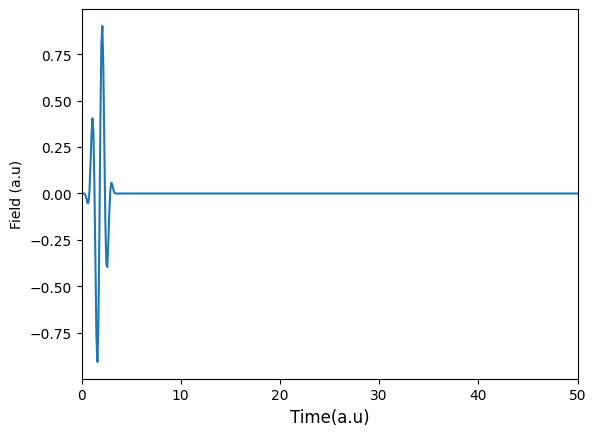

In [ ]:
plt.plot(time,field)
plt.xlabel(r'Time(a.u)', size = 12)
plt.ylabel(r'Field (a.u)')
#plt.plot(time,field_2)
plt.xlim([0, 50])
plt.show()

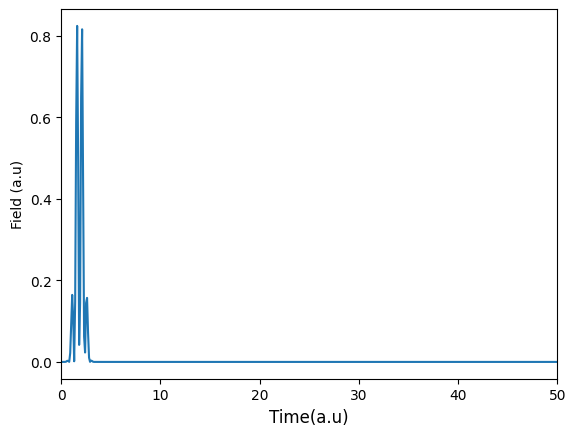

In [ ]:
plt.plot(time,field**2)
plt.xlabel(r'Time(a.u)', size = 12)
plt.ylabel(r'Field (a.u)')
#plt.plot(time,field_2)
plt.xlim([0, 50])
plt.show()

# Performing Fourier Transforms
$$
F(\omega)=\int_{-\infty}^{+\infty} f(t) e^{-i \omega t} d t
$$

In [ ]:
energy = np.arange(40/H2ev,300/H2ev,f/5000)   #Energy axis

In [ ]:
def FT(time, signal, energy):
    sigOutNum = np.zeros(len(energy)).astype(np.complex128)
    kappa = -np.log(1e-3) / time[-1]
    mask = np.exp(-kappa * time)

    signal *= mask
    for ei, e in enumerate(energy):
        sigOutNum[ei] = np.sum(np.exp(1j * e * time) * signal - signal[0])

    sigOutNum *= time[1] - time[0]

    return sigOutNum


# Plotting functions

In [ ]:
field_squared = field**2

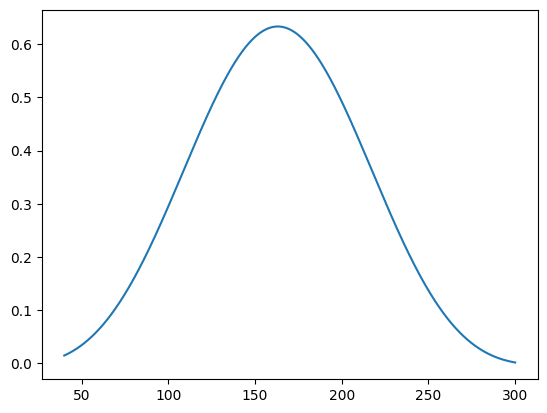

In [ ]:
plt.plot(energy*H2ev,(np.abs(FT(time,field,energy))))
#plt.plot(energy*H2ev,(np.real(FT(time,field,energy))))

#Performing FT using FFT

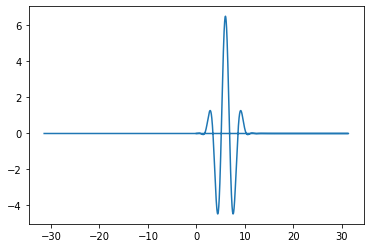

In [ ]:
time  = np.array(time)
field = np.array(field)

field_FT = np.fft.rfft(field)
freq     = np.fft.fftfreq( len(time) )[:len(field_FT)]
freq     = freq*2*np.pi/dt

# plot the frequency domain
plt.plot(freq,np.real(field_FT))
plt.show()

